# Bank Marketing Analytics: Predicting Term Deposit Subscriptions
### Bridging marketing campaign data with financial outcomes

**Author:** Juliet Asantewaa Sarpong  
**Tools:** Python, scikit-learn, XGBoost, SHAP, pandas, seaborn  
**Data:** [UCI Bank Marketing dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing) (Moro, Cortez and Rita, 2014): 41,188 phone contacts from a Portuguese bank's campaigns, May 2008 to November 2010

---

A bank runs phone campaigns to sell term deposits. Two questions drive this notebook:

1. **Can we predict which clients will subscribe**, using only information available *before* the call?
2. **What is that prediction worth**, compared with calling clients at random?

The analysis lives in four scripts in `src/`. This notebook runs each one in turn so the code, results and figures stay in sync.

In [1]:
from IPython.display import Image, display
import pandas as pd
pd.set_option("display.width", 140)
FIG_DIR = "figures/"

---
## 1. Exploratory data analysis

In [2]:
%run src/01_eda.py

Loaded 41,188 rows × 21 columns
Conversion rate: 11.3%

=== Dataset Overview ===
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str

=== Missing Values ===
job           330
marital        80
education    1731
default      8597
housing       990
loan          990

=== Target Distribution ===
  no: 36,548 (88.7%)
  yes: 4,640 (11.3%)
Saved: 01_class_balance.png


Saved: 02_numeric_distributions.png


Saved: 03_categorical_conversion.png


Saved: 04_correlation_heatmap.png

✓ EDA complete. Figures saved to figures/


Only **11.3%** of contacts led to a subscription, so accuracy would be a misleading metric: predicting "no" for everyone is 89% accurate. Several columns use `"unknown"` for missing values, most notably `default` (8,597 rows).

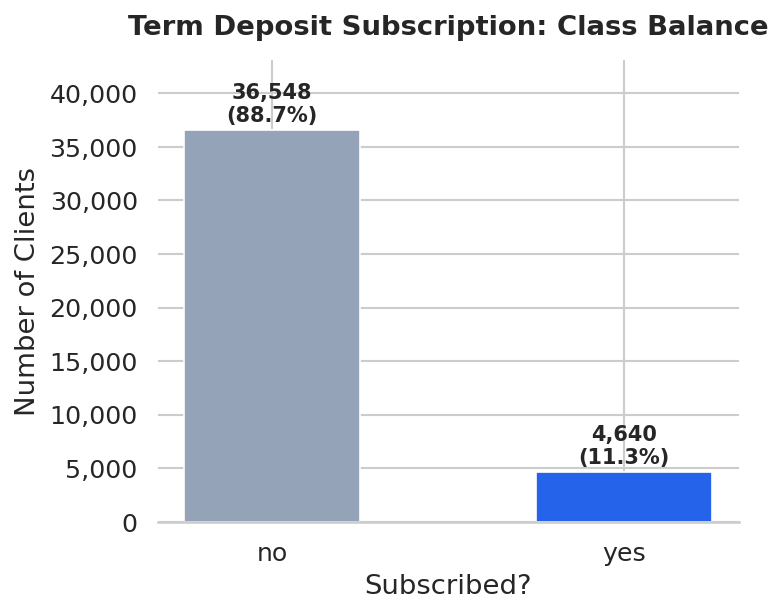

In [3]:
display(Image(FIG_DIR + "01_class_balance.png", width=420))

### 1.1 Numeric features

- **Call duration** separates subscribers very clearly, but it is only known *after* the call ends, so it cannot be used to decide who to call. It is excluded from every model.
- **Contacts this campaign** is right-skewed. Conversion falls from 13% after one contact to about 3% after more than ten.
- **The economic indicators** (`euribor3m`, `emp.var.rate`, `nr.employed`) cluster into a few distinct values, because they change month by month rather than client by client.

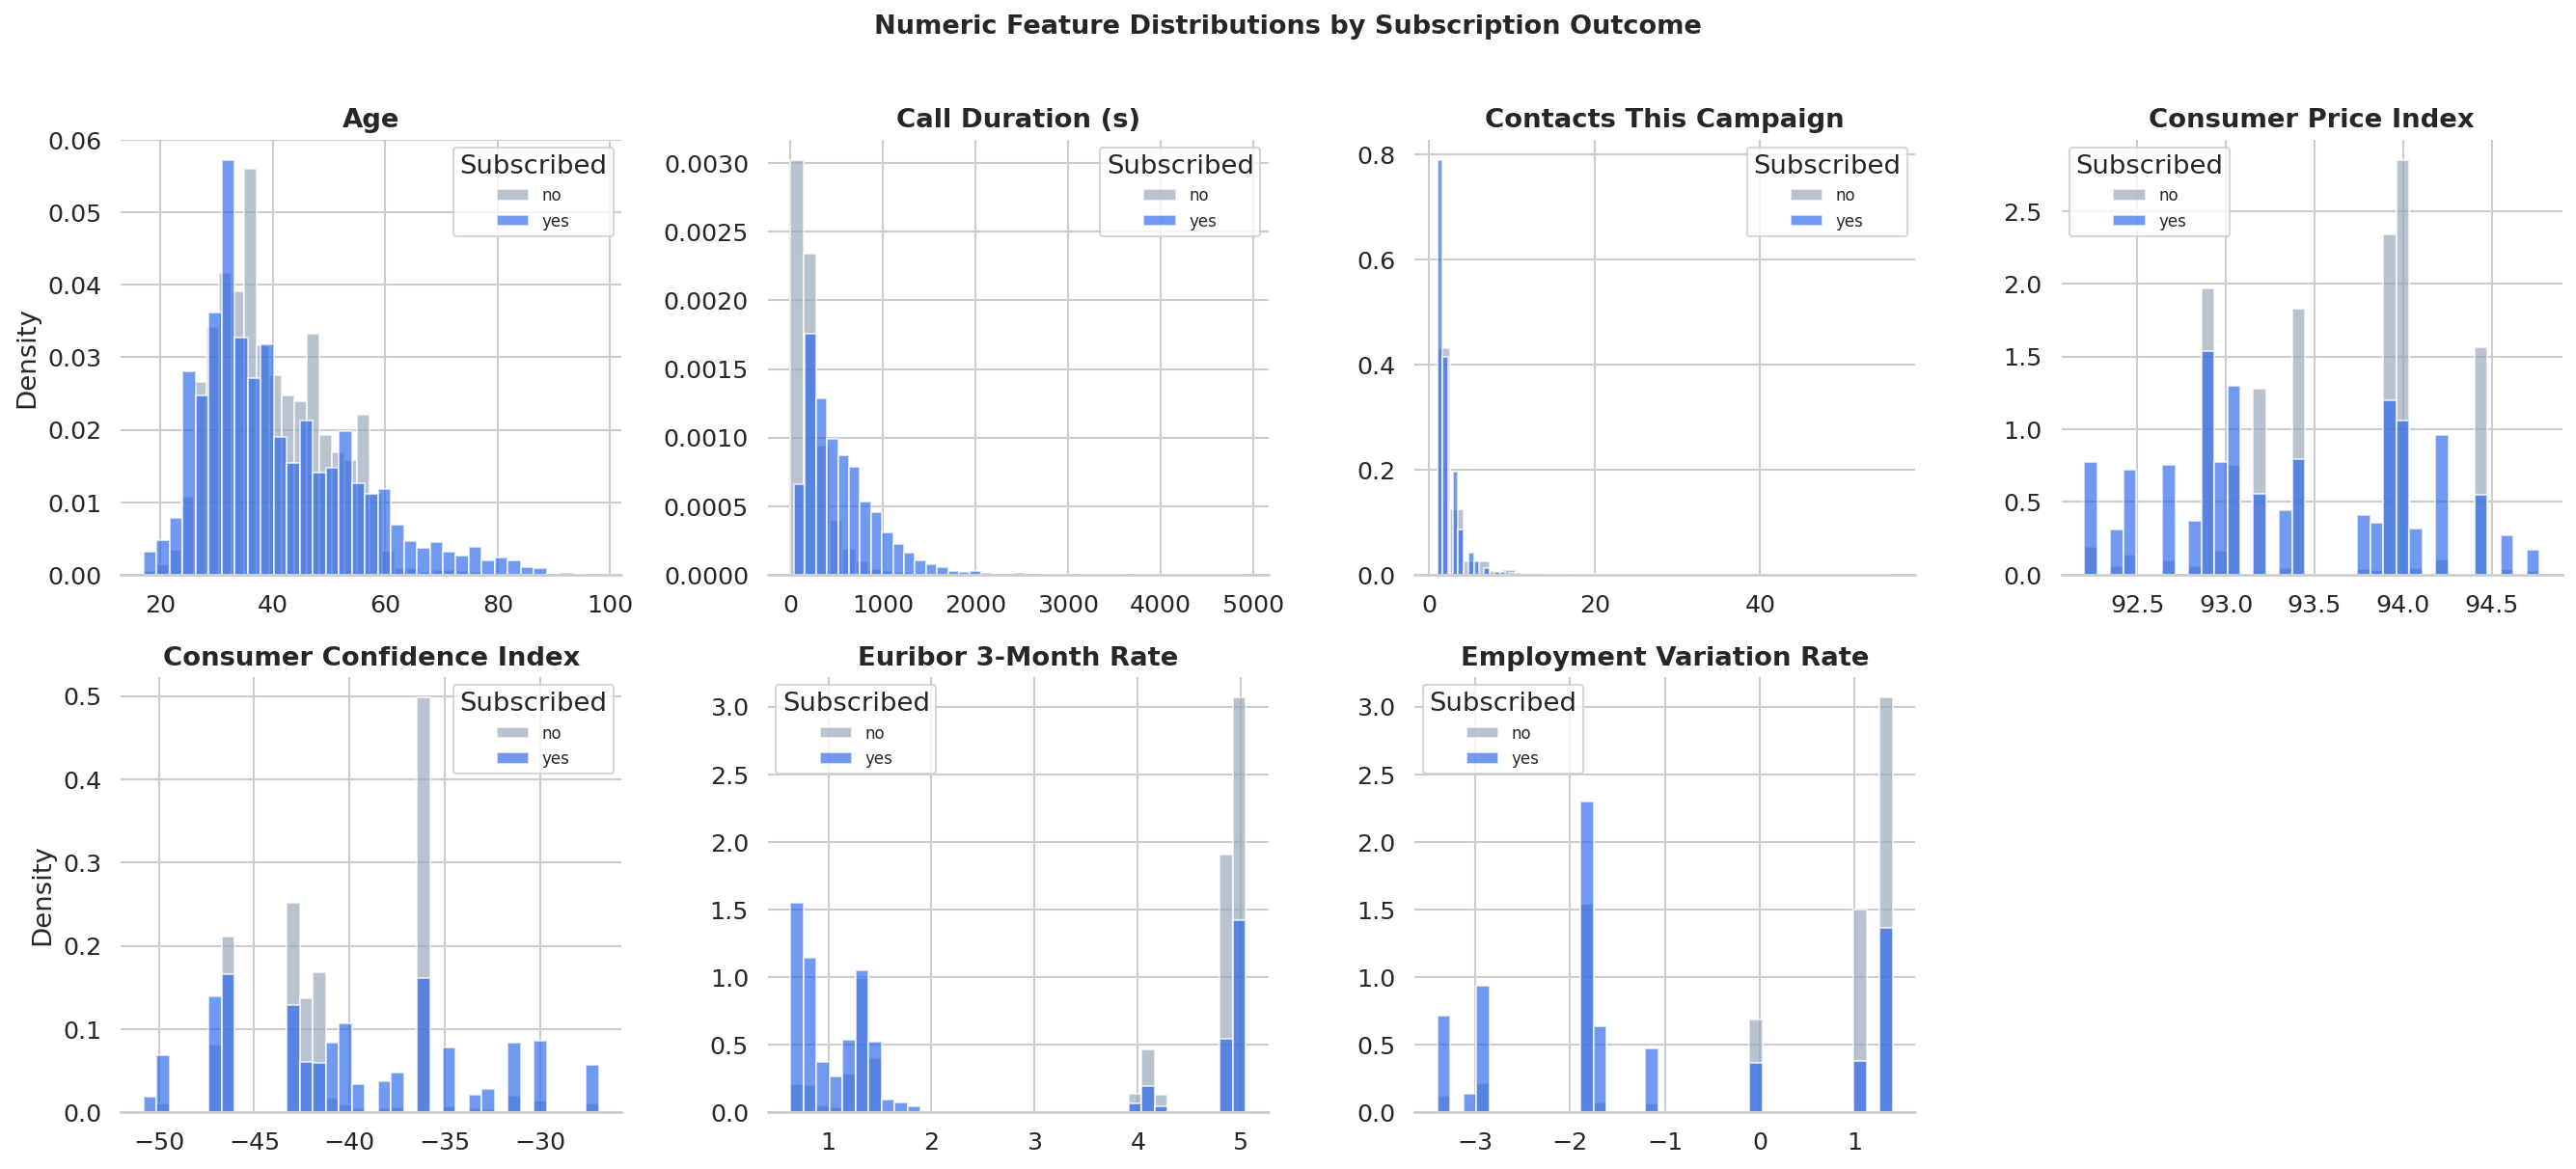

In [4]:
display(Image(FIG_DIR + "02_numeric_distributions.png"))

### 1.2 Conversion by category

- **A successful previous campaign** is the strongest single signal: 65% of those clients subscribed again, against 9% of clients never contacted before.
- **Students (31%) and retirees (25%)** convert far more often than blue-collar workers (7%).
- **Mobile contact (15%)** outperforms landline (5%).
- **March, September, October and December** convert at 44 to 51%, while **May**, by far the busiest month with 13,769 calls, converts at just 6%.

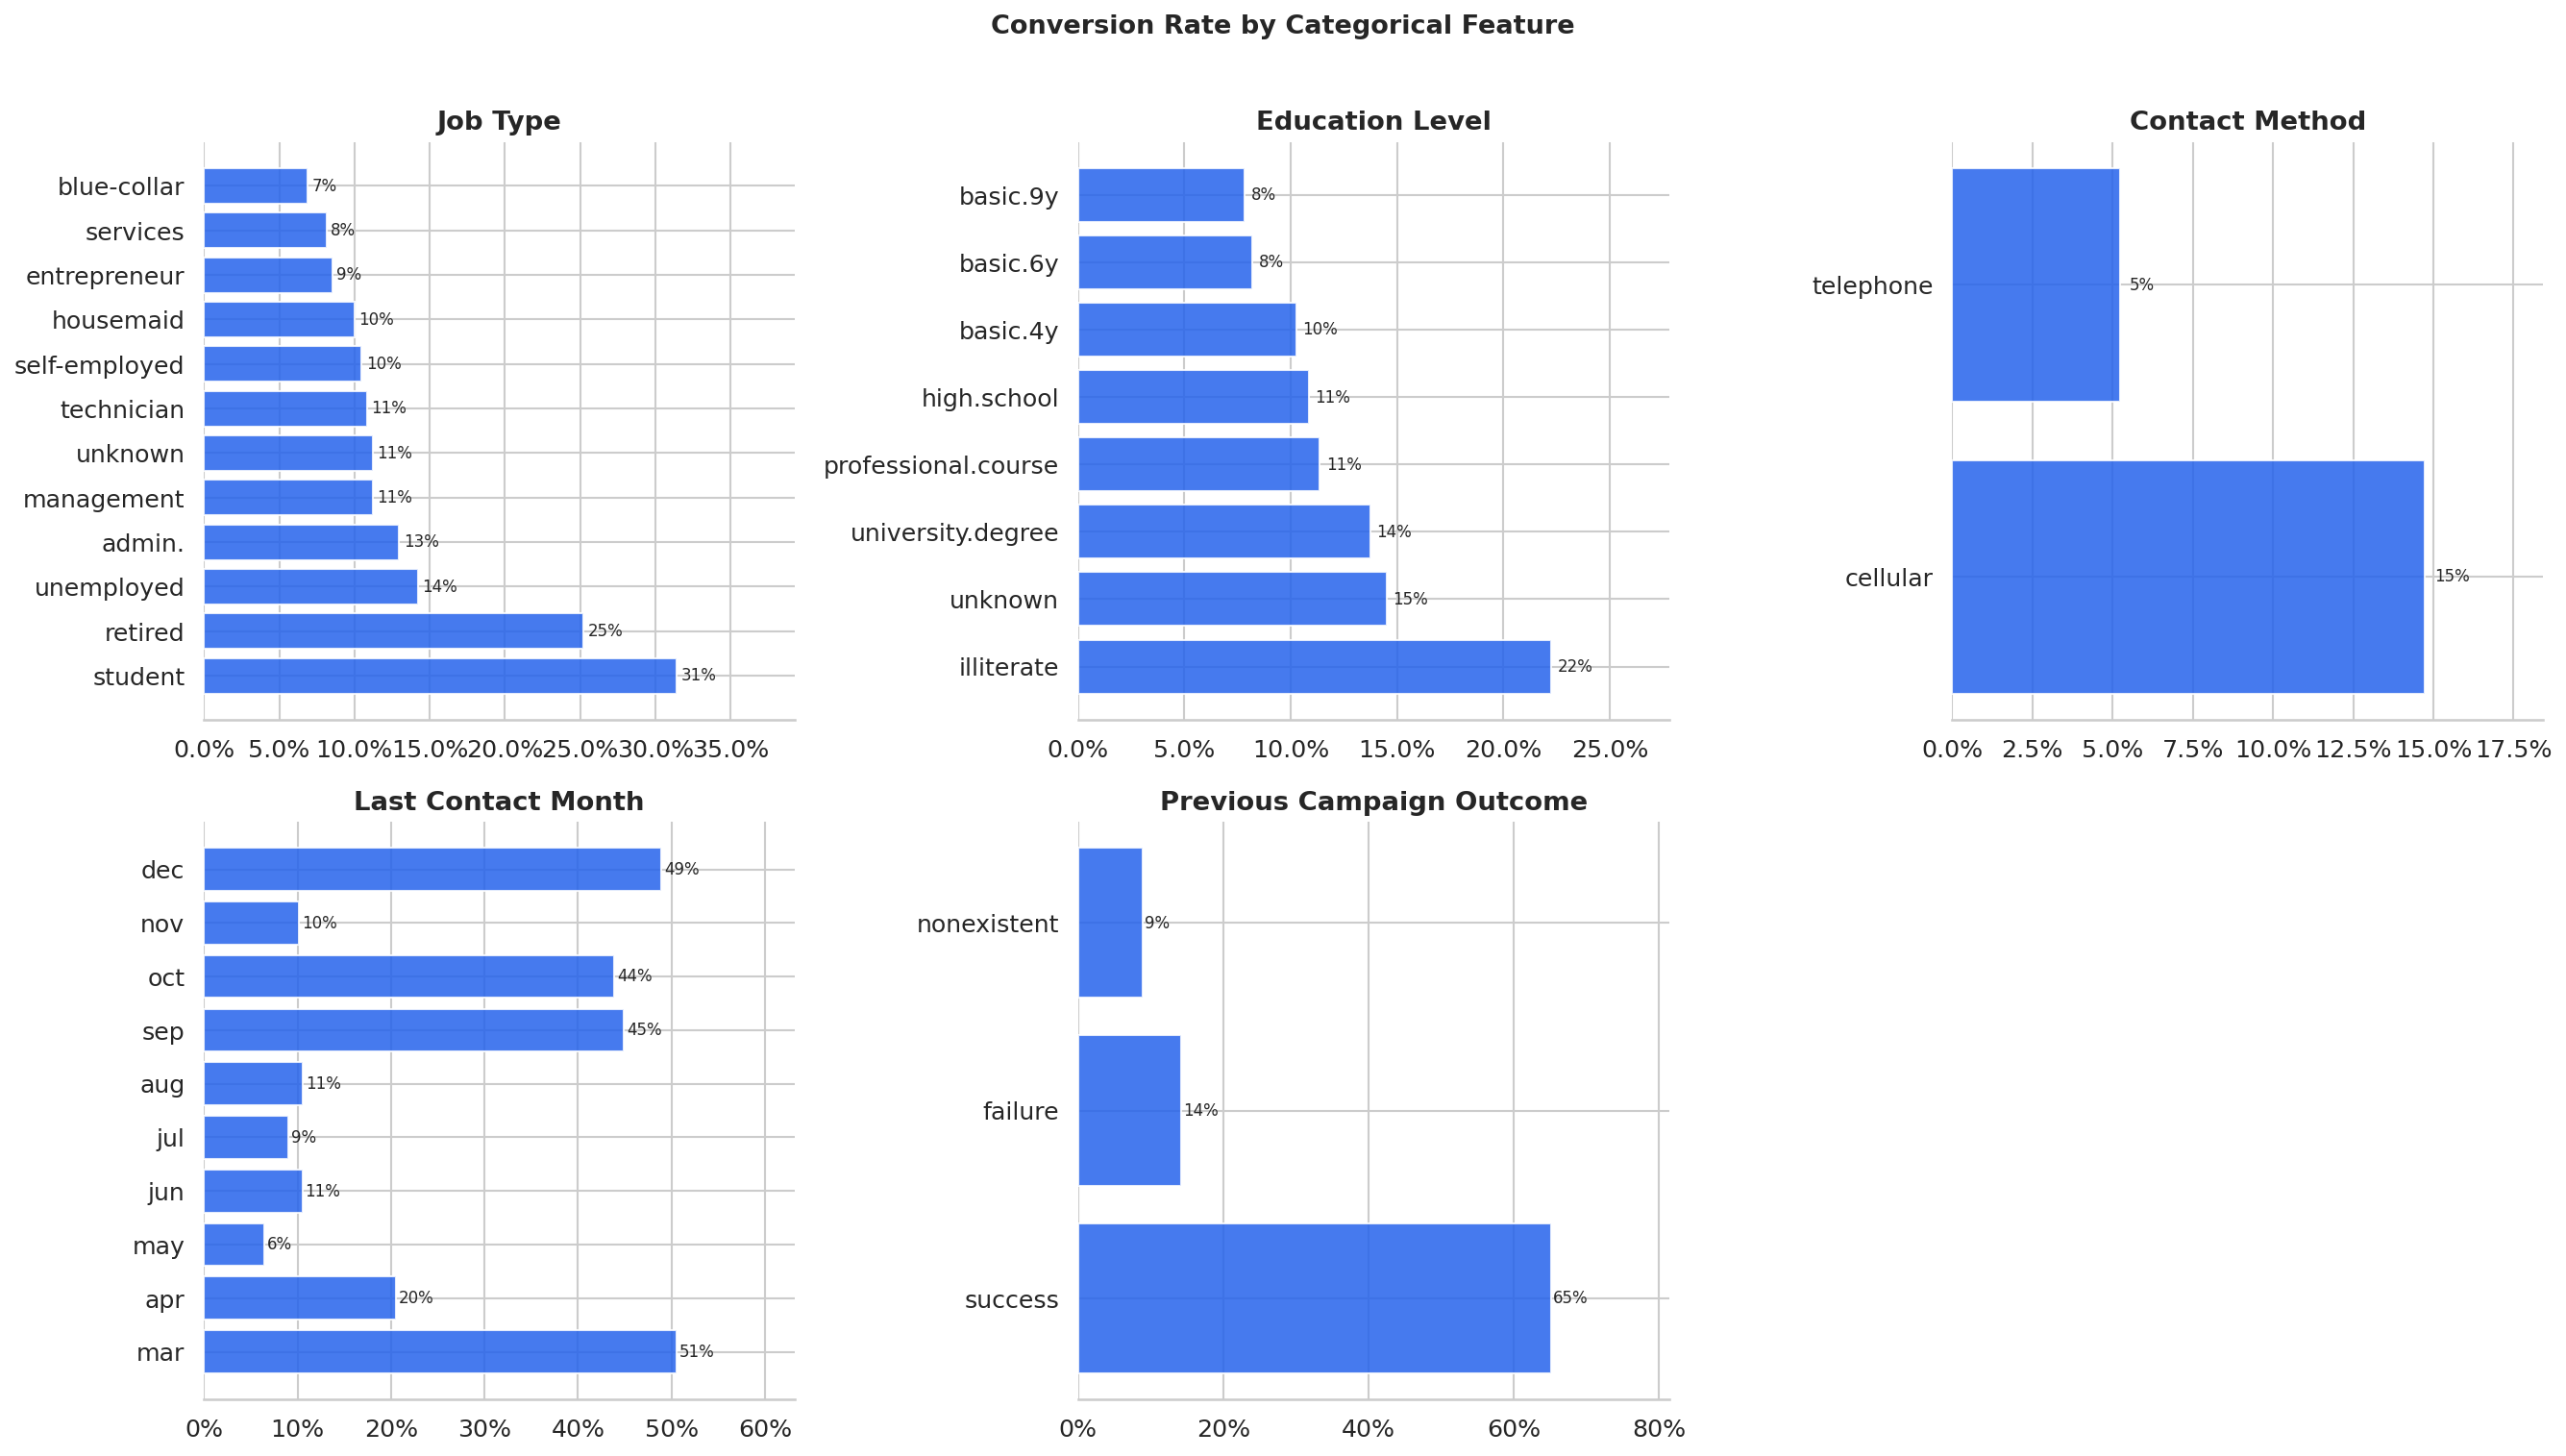

In [5]:
display(Image(FIG_DIR + "03_categorical_conversion.png"))

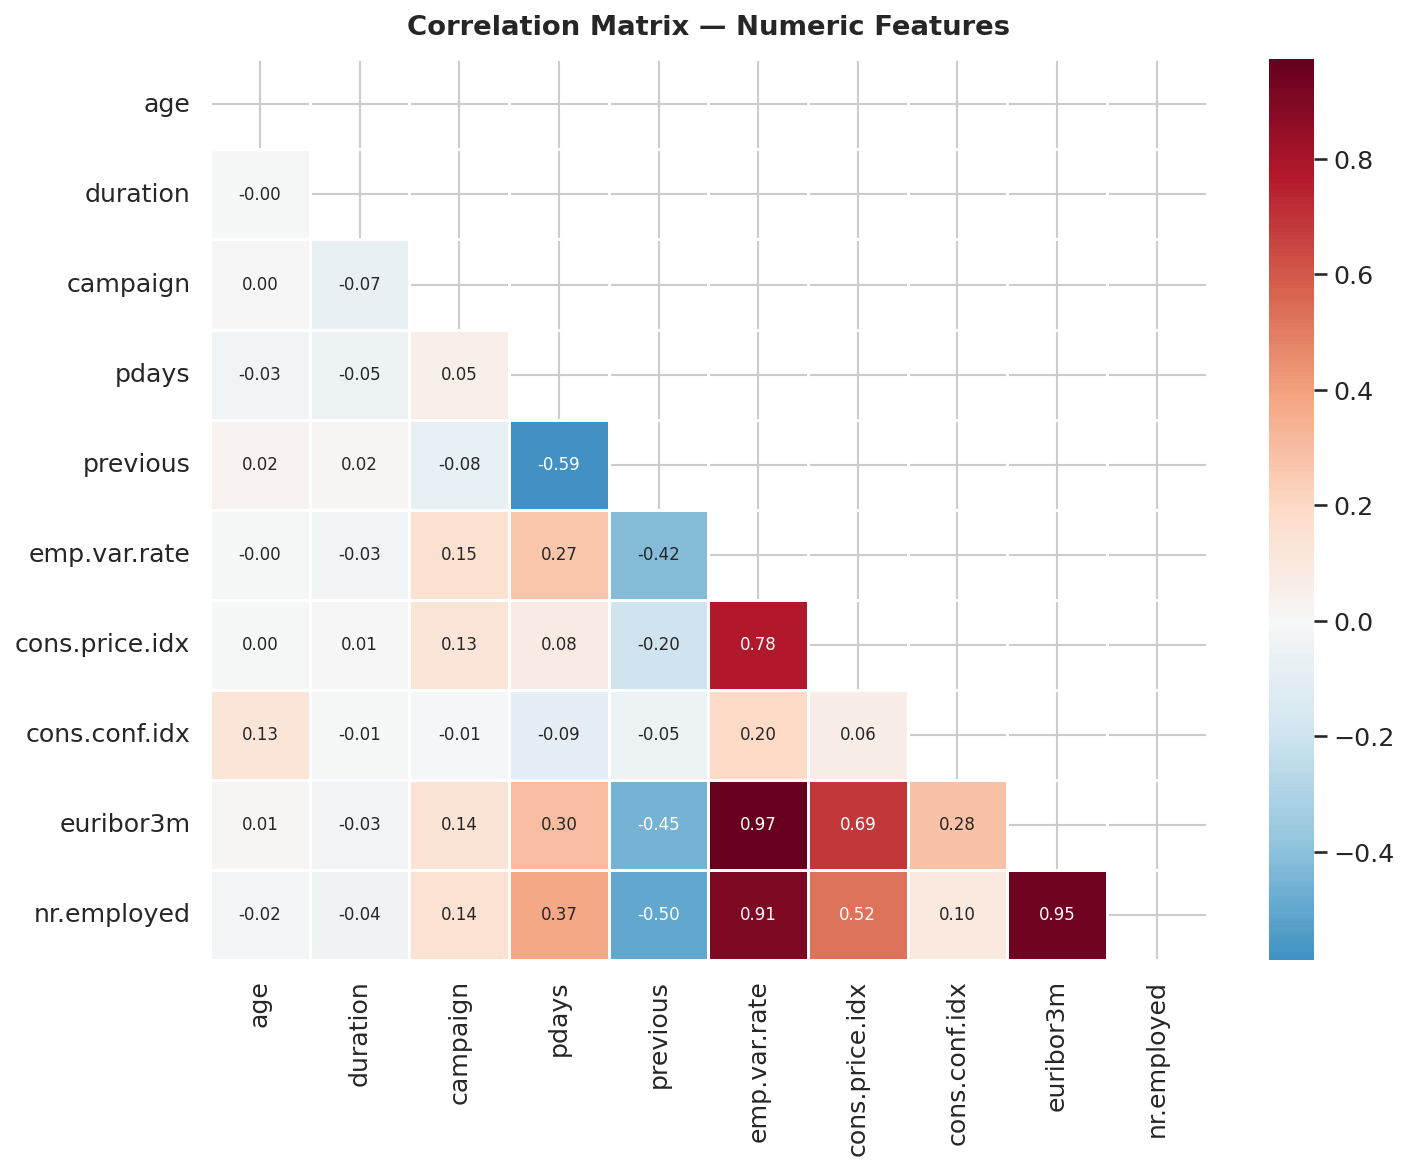

In [6]:
display(Image(FIG_DIR + "04_correlation_heatmap.png", width=640))

The economic indicators are very highly correlated (for example `euribor3m` and `nr.employed` at 0.95). They all describe *when* a call was made, which matters for interpreting the model later.

---
## 2. Feature engineering

`src/02_features.py` imputes `"unknown"` values, adds interpretable features (such as `prior_success`, `contacted_heavily`, `has_loan` and a composite `econ_score`), encodes categories, and makes a stratified 80/20 train/test split. Call `duration` is dropped to avoid leakage.

In [7]:
%run src/02_features.py

=== Feature Engineering Pipeline ===



Train: 32,950 rows | Test: 8,238 rows
Train conversion rate: 11.3%
Test  conversion rate: 11.3%
Features: 31



✓ Splits saved to data/


---
## 3. Predictive modelling

Three classifiers span the interpretability and performance trade-off. Class imbalance is handled with `class_weight="balanced"` and `scale_pos_weight`. Models are compared on ROC-AUC and average precision with 5-fold stratified cross-validation, then evaluated once on the held-out test set. This step takes a few minutes.

In [8]:
%run src/03_model.py

=== Modelling Pipeline ===

Loaded: 32,950 train | 8,238 test rows

[1] Cross-Validation
  CV: Logistic Regression … 

AUC=0.784 ± 0.006
  CV: Random Forest … 

AUC=0.799 ± 0.004
  CV: XGBoost … 

AUC=0.795 ± 0.005

CV Summary:
                     ROC-AUC  ROC-AUC std  Avg Precision  Avg Precision std
Model                                                                      
Logistic Regression    0.784        0.006          0.432              0.004
Random Forest          0.799        0.004          0.468              0.011
XGBoost                0.795        0.005          0.467              0.012

[2] Test Set Evaluation
  Fitting Logistic Regression …


  Fitting Random Forest …


...


[3] Plots


Saved: 05_roc_pr_curves.png


Saved: 06_confusion_matrices.png
Saved: 07_feature_importance.png
  Computing SHAP values (XGBoost) …


Saved: 08_shap_beeswarm.png

=== Test Set Classification Reports ===

--- Logistic Regression ---
              precision    recall  f1-score   support

          No       0.96      0.74      0.83      7310
         Yes       0.26      0.74      0.39       928

    accuracy                           0.74      8238
   macro avg       0.61      0.74      0.61      8238
weighted avg       0.88      0.74      0.78      8238


--- Random Forest ---
              precision    recall  f1-score   support

          No       0.96      0.80      0.87      7310
         Yes       0.31      0.71      0.43       928

    accuracy                           0.79      8238
   macro avg       0.63      0.75      0.65      8238
weighted avg       0.88      0.79      0.82      8238


--- XGBoost ---
              precision    recall  f1-score   support

          No       0.95      0.90      0.92      7310
         Yes       0.44      0.63      0.52       928

    accuracy                           0.87 

  Time-based split (train on earliest 80%, test on latest 20%): ROC-AUC = 0.730
  Conversion rate: 6.4% in training period vs 30.8% in test period

✓ Modelling complete.


In [9]:
pd.read_csv("outputs/test_metrics.csv", index_col=0).round(3)

,ROC-AUC,Avg Precision
Logistic Regression,0.795,0.455
Random Forest,0.814,0.489
XGBoost,0.814,0.493


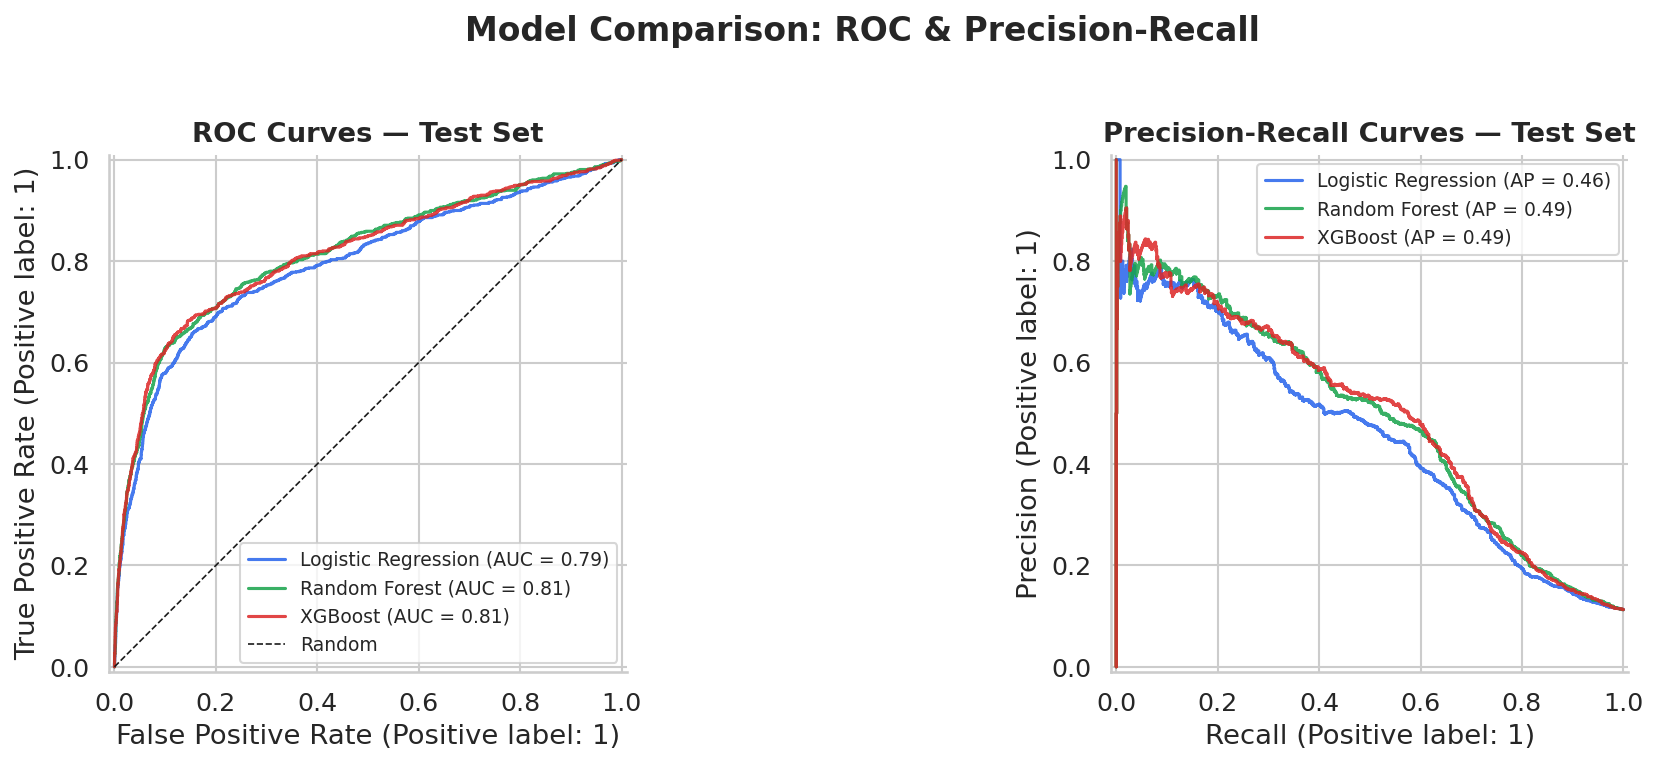

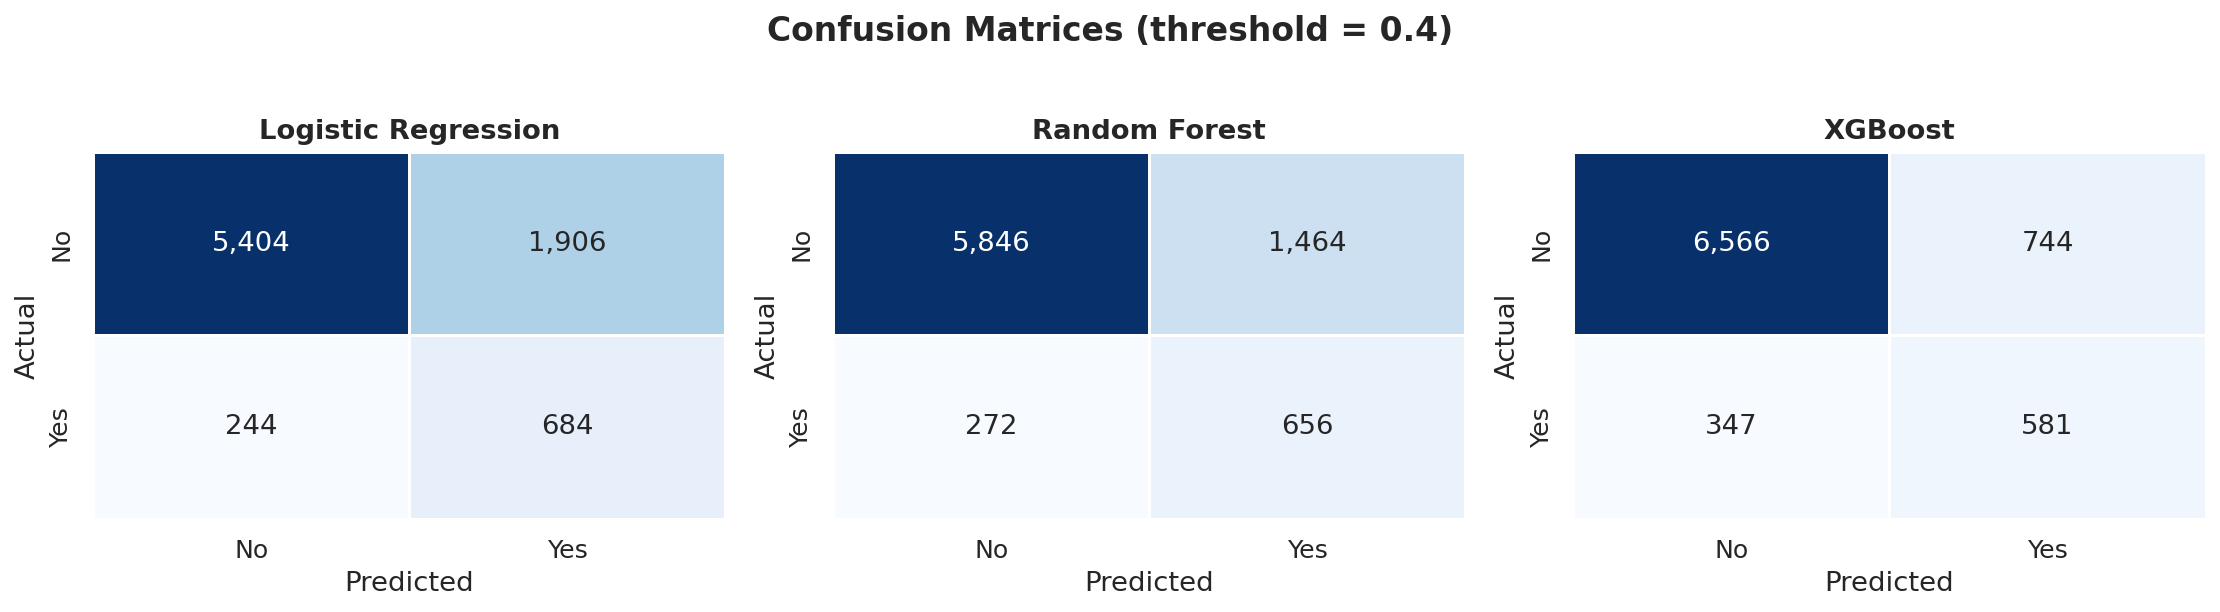

In [10]:
display(Image(FIG_DIR + "05_roc_pr_curves.png"))
display(Image(FIG_DIR + "06_confusion_matrices.png"))

**Reading the results.** Random Forest and XGBoost are effectively tied (test ROC-AUC 0.814) and both beat logistic regression (0.795). An AUC around 0.8 without call duration is in line with published results on this dataset. At a 0.4 threshold, XGBoost finds 63% of subscribers with 44% precision.

**A stricter test.** A random split lets the model learn from calls made in the same months it is tested on. Training on the earliest 80% of contacts and testing on the latest 20% gives a lower **ROC-AUC of 0.73**, and the conversion rate jumps from 6% to 31% between those periods. Any real deployment would need regular retraining and monitoring for this kind of drift.

---
## 4. Model interpretation

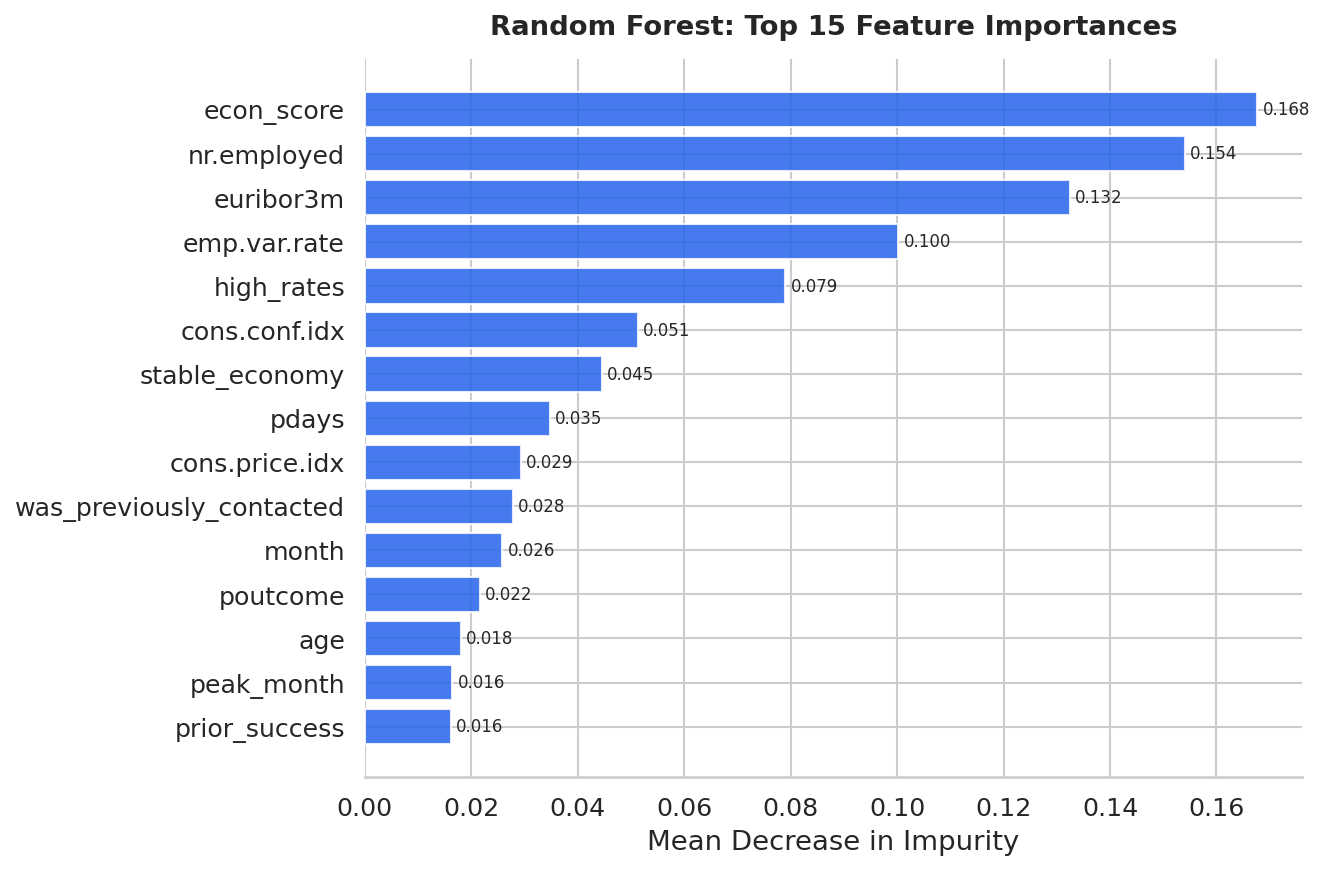

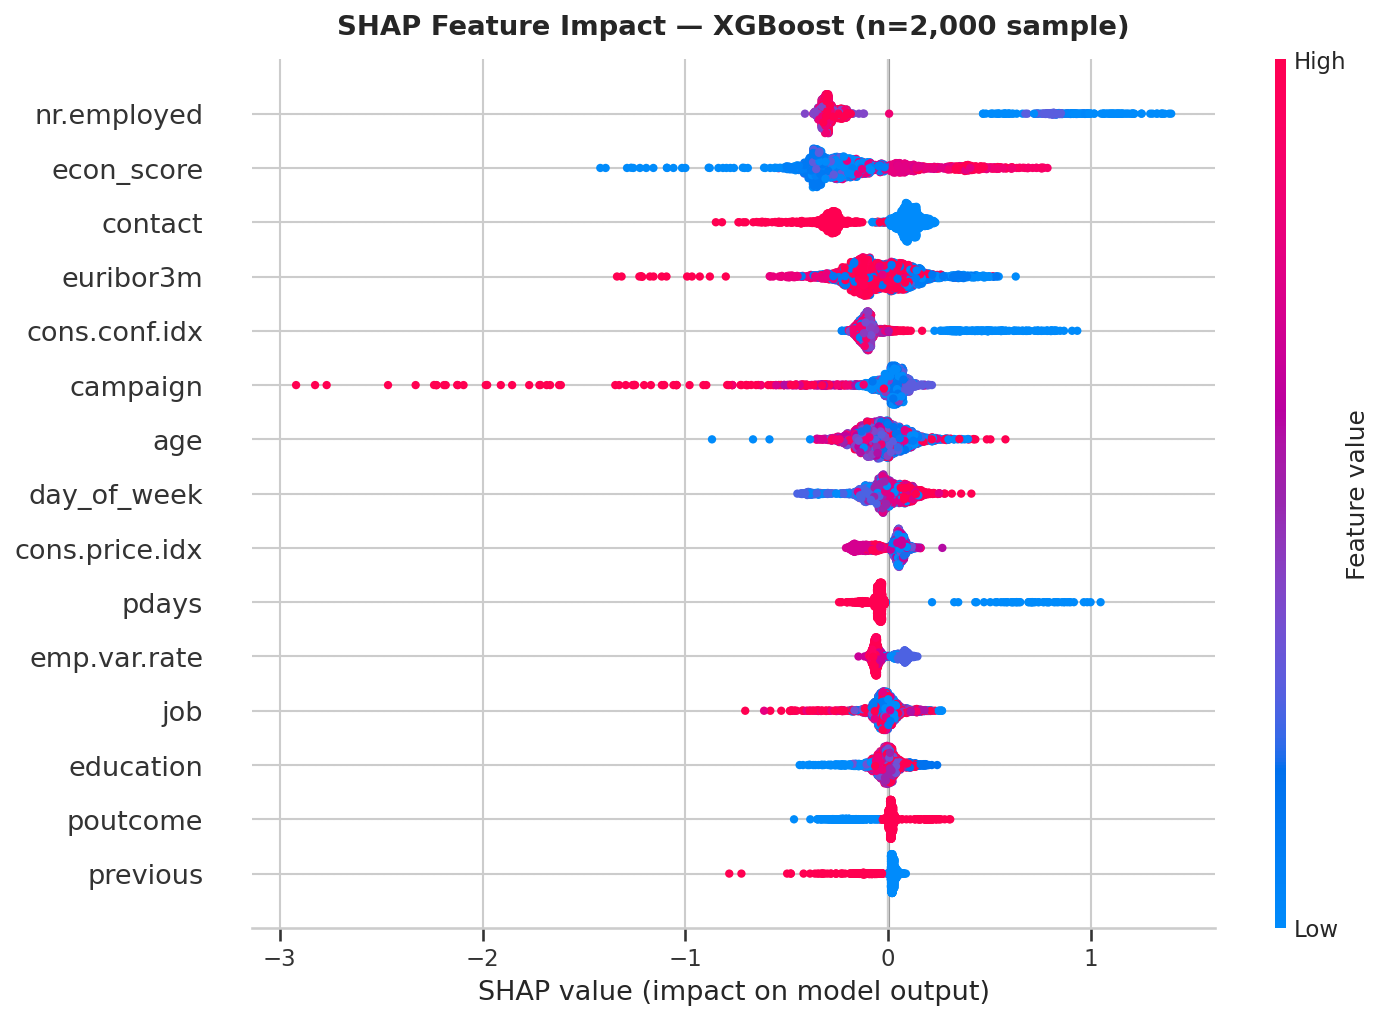

In [11]:
display(Image(FIG_DIR + "07_feature_importance.png", width=620))
display(Image(FIG_DIR + "08_shap_beeswarm.png", width=700))

**Key SHAP findings (XGBoost):**

- **Economic context dominates.** Low `nr.employed`, low `euribor3m` and low consumer confidence all push predictions up. In this data these conditions coincide with the 2009 to 2010 period, when the bank ran smaller, more targeted campaigns, so they mainly capture *when* a call was made.
- **Mobile contact helps**, landline (`contact`) hurts.
- **More contacts this campaign** (`campaign`) sharply lowers the prediction.
- **Recent previous contact** (low `pdays`) and a successful previous campaign (`poutcome`) raise it.

> **Prediction is not causation.** SHAP shows what the model relies on, not what would happen if we changed something. For example, clients called many times may simply be harder to convince, so capping calls would not necessarily raise conversion. Estimating the effect of a policy like that needs a causal design, such as a randomised test or causal inference methods like TMLE.

---
## 5. Business value

Assumptions: **£150 revenue** per subscription (1.5% margin on a £10,000 deposit) and **£5 per call**. All results use the held-out test set of 8,238 clients.

In [12]:
%run src/04_business_value.py

=== Business Value Pipeline ===



Model: Random Forest | Test rows: 8,238


Saved: 09_strategy_comparison.png


Saved: 10_lift_curve.png
Saved: 11_precision_at_k.png

=== Business Value Summary ===
     Strategy  Clients Contacted  Conversions Conversion Rate Converters Captured Net Profit (£) Cost / Conversion
Call everyone               8238          928           11.3%              100.0%        £98,010            £44.39
   Random 30%               2471          278           11.3%               30.0%        £29,398            £44.39
Model top 30%               2471          692           28.0%               74.6%        £91,445            £17.85
Model top 15%               1235          564           45.7%               60.8%        £78,425            £10.95

  At a 30% budget the model wins 2.5x as many subscriptions as random calling
  Calling only the top 30% keeps 93% of the profit of calling everyone with 70% fewer calls
  Profit peaks at £99,125 when calling the top 88%

  Assumptions: £150 revenue per subscription, £5 per call

✓ Business value analysis complete.


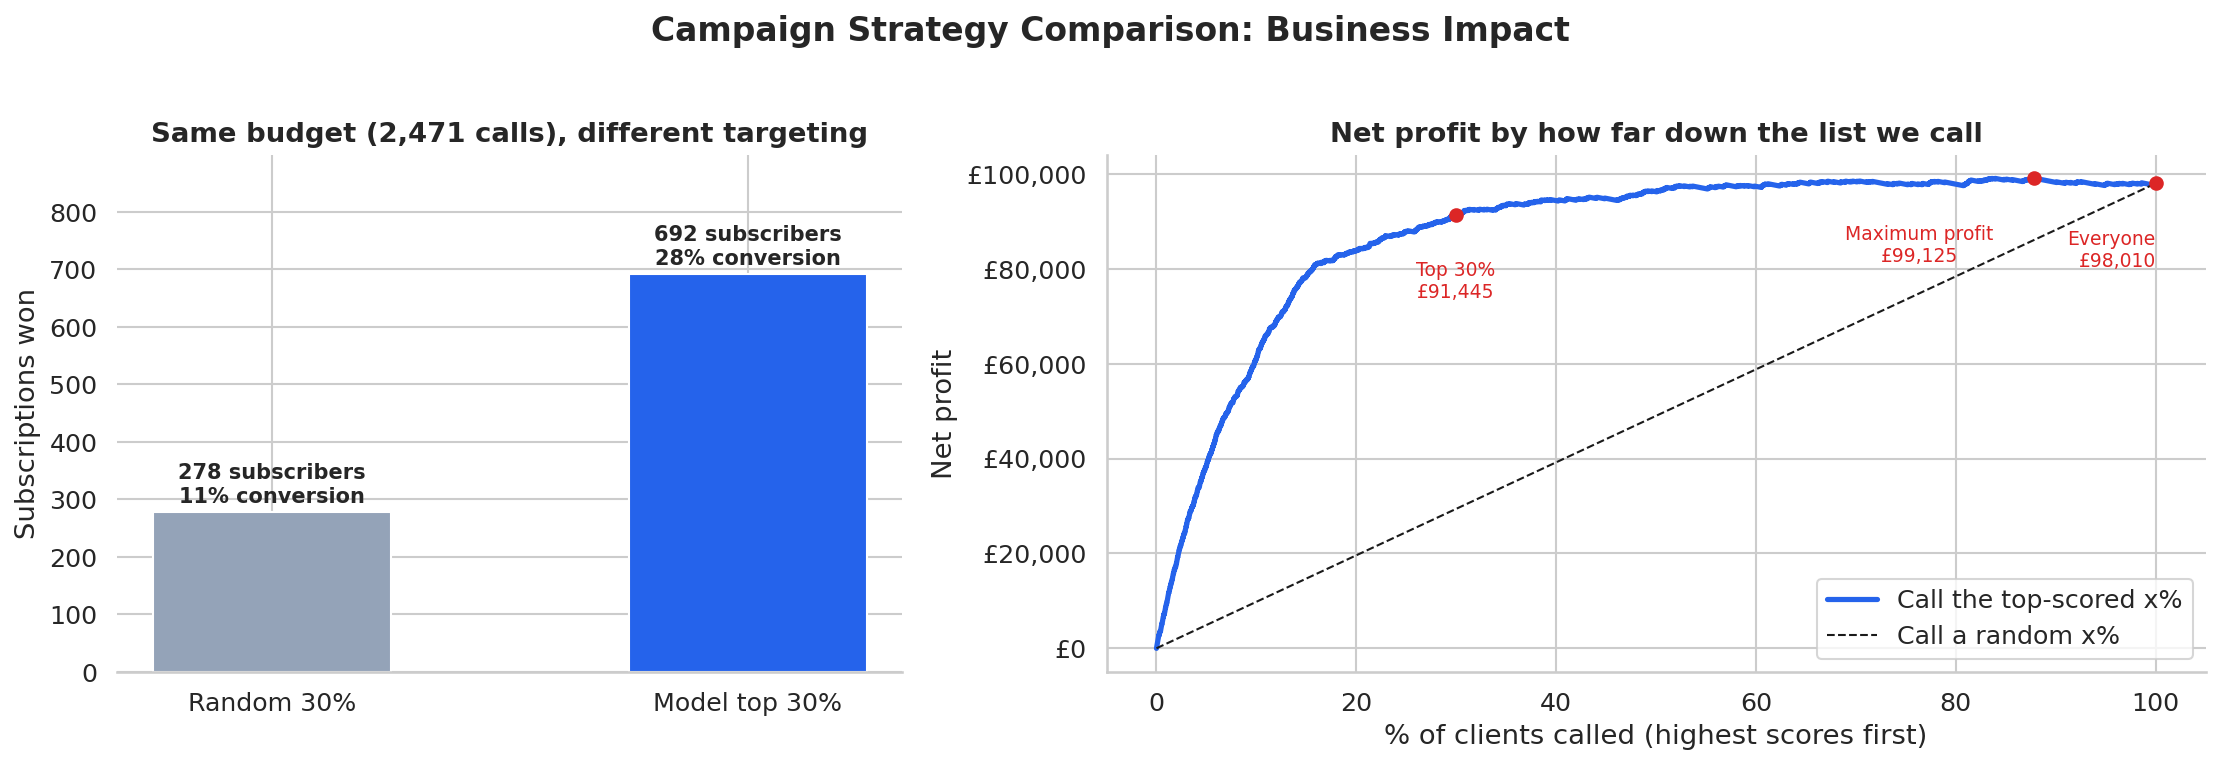

In [13]:
display(Image(FIG_DIR + "09_strategy_comparison.png"))

**The model's value is in targeting under a limited budget.**

- If the call centre can reach **30% of the list**, calling the model's top-scored clients wins **692 subscriptions versus 278 at random, 2.5 times as many**, at £17.85 per subscription instead of £44.39.
- Because a subscription is worth 30 times the cost of a call, calling *everyone* is still profitable (£98,010). But calling only the top 30% keeps **93% of that profit with 70% fewer calls**, freeing about 5,800 calls of capacity for other work.
- Profit peaks at **£99,125 when calling the top 88%**. Below that point, the least likely clients convert at about 3%, under the 3.3% break-even rate.

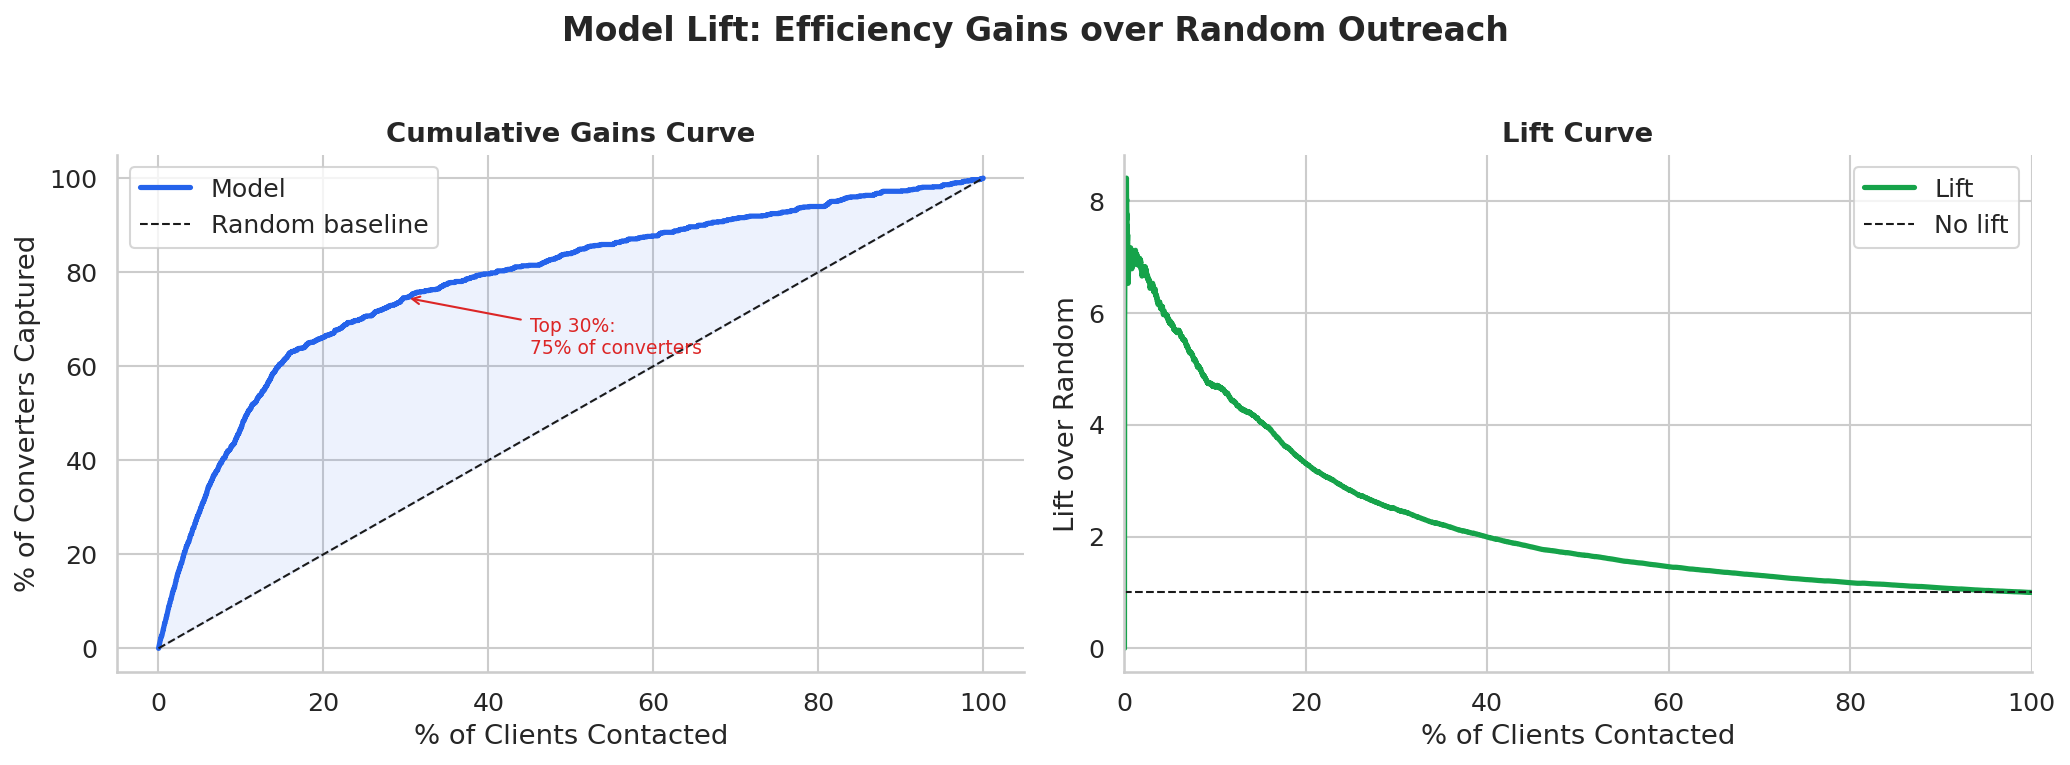

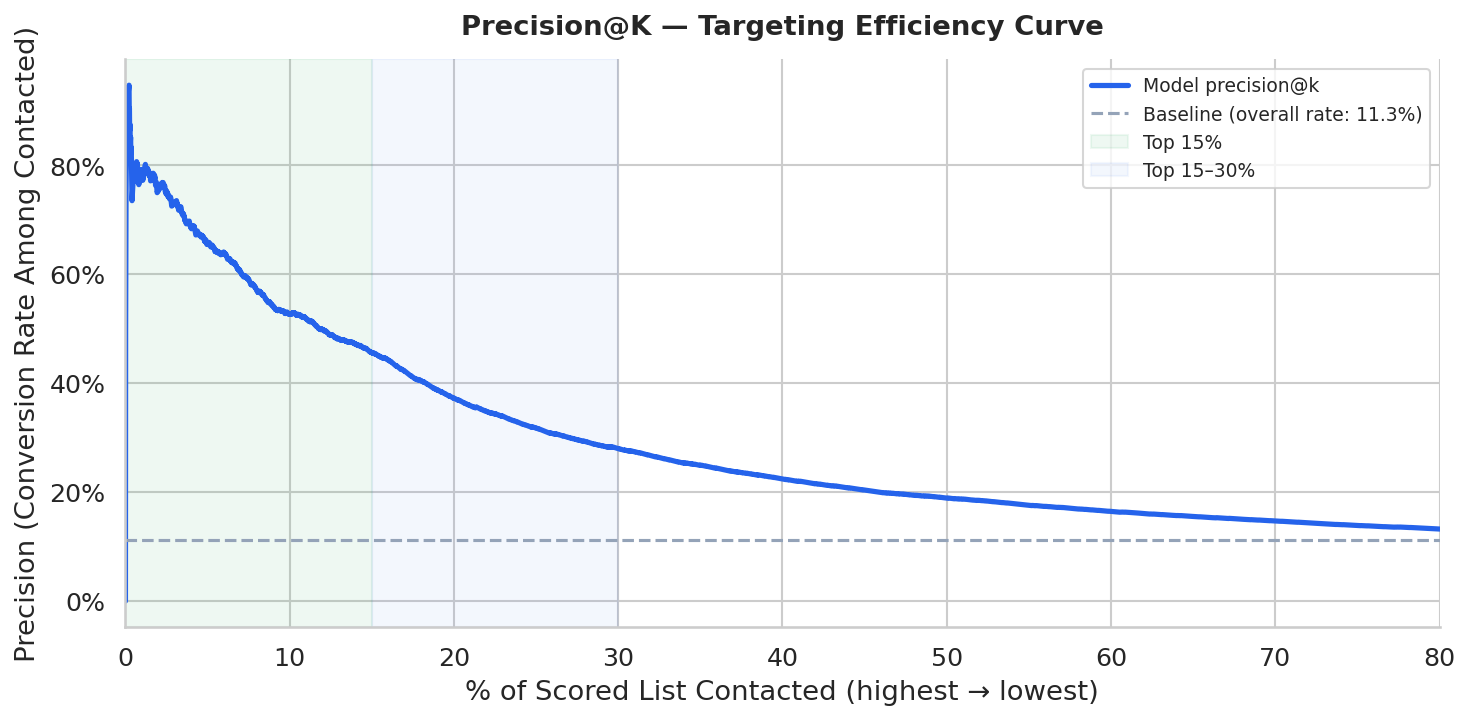

In [14]:
display(Image(FIG_DIR + "10_lift_curve.png"))
display(Image(FIG_DIR + "11_precision_at_k.png", width=700))

---
## 6. Summary

| Finding | Implication |
|---|---|
| Random Forest and XGBoost reach ROC-AUC 0.81 without call duration | Useful for prioritising who to call |
| Top 30% of scores captures 75% of subscribers | 2.5 times the subscriptions of random calling at the same budget |
| Calling the top 30% keeps 93% of total profit with 70% fewer calls | Frees capacity when the call centre is the constraint |
| Previous campaign success is the strongest client-level signal | Prioritise past subscribers in future campaigns |
| Heavy contact is associated with lower conversion | Worth testing a contact cap with a randomised experiment |
| Performance drops to AUC 0.73 on a time-based split | Retrain regularly and monitor for drift |

### Limitations

- **Time effects.** The economic indicators largely encode the time period, so part of the model's accuracy reflects *when* calls were made. The time-based check shows the realistic out-of-sample performance is lower.
- **Illustrative economics.** The £150 and £5 figures are assumptions, and the conclusions about how far down the list to call depend on them. They are set at the top of `src/04_business_value.py`.
- **Associations only.** None of the findings above are causal effects.